<a href="https://colab.research.google.com/github/jmcardenas8/Notebooks-Pregrado-Astronomia/blob/main/Astrofisica-moderna/proyecto_comp2_astromod.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Simulacion de la Distribucion estelar en una Galaxia**
<br>

#### **Astrofisica moderna:** Proyecto computacional 2
##### Prof. German Chaparro Molano

> Juan Manuel Cardenas
<br>

In [ ]:
# librerias
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as cts
import astropy.constants as astrocts
from astropy import units as unit
from tqdm import tqdm
%matplotlib inline

plt.style.use('seaborn-v0_8-dark-palette')

La mayorıa de la radiacion interestelar proviene de luz emitida por las estrellas mas masivas (tipo O). El numero aproximado de estas estrellas en la Vıa Lactea es $N_{O*}≈5×10^4$, y su luminosidad individual es aproximadamente $L_{O*}≈10^{40} \text{erg s}^{-1}$

In [ ]:
# Constantes importantes
c = cts.c              # velocidad luz [m/s]
h = cts.h              # plank [J*s]
k = cts.k              # boltzmann [J/K]
pi = np.pi             # valor de pi
rad = np.pi/180        # factor [deg] a [rads]
pc = unit.pc           # parsec [pc]
pc_m = pc.to(unit.m)   # parsec [m]
pc_cm = pc.to(unit.cm) # parsec [cm]

# Parametros de la galaxia
No_star = int(5e4) # numero de estrellas O
Lo = 10**40        # luminosidad O* [erg/s]
L = 1              # luminosidad O* [1 Lo]
r_gal = 36         # radio [kpc]

### **A) Simulacion de la distribucion estelar en una galaxia**

(1 pt) Simule la distribucion de estas estrellas en la Vıa Lactea como si estuvieran todas localizadas sobre
un disco y distribuidas de manera aleatoria (uniforme) a lo largo y ancho de un area circular con radio $r_{\text{gal}}$. Haga una grafica 2D que muestre la distribucion de las estrellas como puntos aleatoriamente distribuidos en un disco de radio $r_{\text{gal}}$ (tome $r_{\text{gal}} ≈ 36$ kpc).
<br>

**Definicion de funciones a emplear:**


In [ ]:
# condicion circulo
Bool_cond = lambda x,y: ((x**2+y**2)**0.5 < r_gal)
Flux = lambda L,R: L/(4*pi*R**2)
Dist = lambda x,y: (x**2+y**2)**0.5

Debido a que la distribucion uniforme ejecutada en coordenadas polares generaba un exceso anormal de poblacion de estrellas en el centro debido a la geometria del circulo, se adoptó la distribucion inspirada por el Profesor German Chaparro, generando la distribucion en un cuadrado de lado $2R$ que con mascara booleana se seleccionó solo la region comprendida por el circulo de radio $R$. Para que el numero de estrellas coincidiera se asumio densidad de estrellas por area constante, con lo que se obitne:

$$N_{cuadro} = N_{circulo} \frac{A_{cuadro}}{A_{circulo}} $$

In [ ]:
N_cuad = round(No_star*(4/pi)) # numero de estrellas en cuadrado

def star_distribution():
  # generacion de coordenadas estrellas
  x_c, y_c = np.random.uniform(-r_gal, r_gal, (2,N_cuad))
  x = x_c[Bool_cond(x_c,y_c)] # condicion dentro de circulo
  y = y_c[Bool_cond(x_c,y_c)]

  # en polares
  r = (x**2+y**2)**0.5
  theta = np.arctan2(y,x)

  return x,y,r,theta

x,y,r,theta = star_distribution()

**Grafica de la simulacion de distribucion estelar**

Empleando la projeccion polar

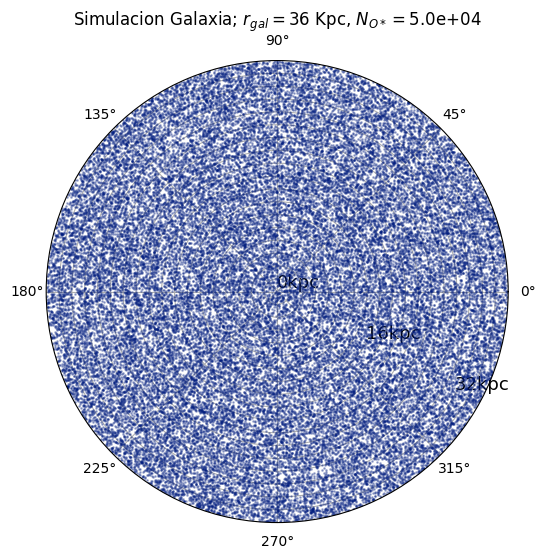

In [ ]:
# configuracion de ticks
ticks = np.arange(0,r_gal,2)
label = [str(t)+'kpc' if i%8==0 else '' for i,t in enumerate(ticks)]

# figura polar
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
ax.set_title(f'Simulacion Galaxia; $r_{{gal}}=${r_gal} Kpc, $N_{{O*}}=${len(x):.1e}', va='top')

ax.set_rticks(ticks)
ax.plot(theta, r, '.', markersize=2, alpha=0.3)
ax.set_yticklabels(label, fontsize=13, alpha=1)
ax.set_rlabel_position(-30)
fig.set_size_inches(6,6)
ax.set_rmax(r_gal)
ax.grid(True)
plt.show()

### **B). Flujo $F_{ISM}$**

(1.5 pt) Usando la distribucion estelar generada en (A) calcule el **flujo $F_{ISM}$** [ erg s$^{-1}$ cm$^{-2}$ ] de todas las estrellas tipo O sobre cada uno de los puntos ubicados entre el centro de la Vıa Lactea ($r = 0$) y el borde ($r = 36$ kpc) a intervalos de $2$ kpc. Para evitar el efecto que tendrıa el estar anormalmente cerca a una estrella O, es necesario correr varias simulaciones distintas y **tomar el minimo valor de flujo** que aparezca para cada r. Con estos resultados haga una grafica de **$F_{ISM}$ vs $r$**.

*Pista:* Los flujos deberian dar por el orden de $10^{-2}$ erg $s^{-1}$ cm$^{-2}$



In [ ]:
n_sims = 2 # numero de simulaciones
n_dir = 4  # numero de direcciones

Como se requiere calcular el flujo con y sin extincion en este y el siguiente punto, se definió una funcion para calcular el flujo de cada estrella en cada punto. Tomando un par de simulaciones y 4 direcciones(para evitar muchas simulaciones) para el calculo del flujo total de las estrellas cada $2$ Kpc del centro al borde dadas las sub funciones para el calculo del flujo de una estrella, y la distancia dadas sus componentes.

In [ ]:
def Flux_All_Stars(Distancia, Flujo):

  flux = []
  for _ in tqdm(range(n_sims)): # Cada simulacion
    flux_gal = []
    x,y,r,theta = star_distribution()

    for i in range(n_dir): # Cada direccion
      flux_dir = []        # reinicio de flujos

      for tick in ticks:   # Cada 2 kpc
        # direcciones
        dir1 = np.array([tick,0,-tick,0])
        dir2 = np.array([0,tick,0,-tick])

        # componentes de distancia a cada estrella
        Rx = x - dir1[i]
        Ry = y - dir2[i]
        R = Distancia(Rx, Ry) # distancia a cada estrella
        F = Flujo(L, R)  # flujo de toda estrella

        flux_dir.append(sum(F))
      flux_gal.append(flux_dir)
    flux.append(flux_gal)
  return np.array(flux) # [Lo/kpc^2]

flux = Flux_All_Stars(Dist, Flux)

100%|██████████| 2/2 [00:00<00:00,  2.11it/s]


la funcion **np.minimum.reduce** toma los valores minimos por cada componente dados varios arreglos

In [ ]:
# tomando los flujos minimos [Lo/kpc^2]
flux_min = np.minimum.reduce([flux[i,j,:] for i in range(n_sims) \
                                          for j in range(n_dir) ])

# volviendo a unidades [erg / s cm^2]
flux_min = flux_min*Lo/((1e3*pc_cm)**2)

#### **Grafica del flujo**

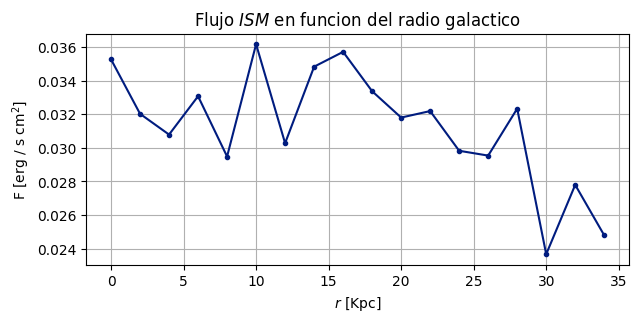

In [ ]:
fig = plt.figure(figsize=(7,3))
plt.title('Flujo $ISM$ en funcion del radio galactico')
plt.plot(ticks, flux_min, '.-')
plt.ylabel('F [erg / s cm$^{2}$]')
plt.xlabel('$r$ [Kpc]')
plt.grid()

### **C) Flujo FISM con extincion**
(1.5 pt) Repita el punto anterior considerando un coeficiente de extincion $a_λ = 1.5$ mag kpc$^{-1}$

* *Pista*: los flujos deberıan dar un orden de magnitud por debajo de los valores del punto (B)
<br>

Si se introduce extincion, esta hara parecer que las estrellas se encuentren mas lejos de la distancia real, que se supone es la posicion de las estrellas en la simulacion, la extincion afecta la distancia asi:

$$ d_{\ \text{aparent}} = d_{\ \text{real}} 10^{A_λ / 5}$$

Con el coeficiente de extincion: $A_λ = a_λ * R $

In [ ]:
# coeficiente de extincion
a_λ = 1.5

Dist_extint = lambda x,y: Dist(x,y) * 10**(a_λ*Dist(x,y)/5)

In [ ]:
# calculando el flujo extinguido por los dos metodos
flux_extint = Flux_All_Stars(Dist_extint, Flux)

100%|██████████| 2/2 [00:01<00:00,  1.79it/s]


In [ ]:
# tomando los flujos minimos
fluxmin_extint = np.minimum.reduce([flux_extint[i,j,:] for i in range(n_sims)\
                                                  for j in range(n_dir) ])

fluxmin_extint = fluxmin_extint * Lo/((1e3*pc_cm)**2) # [erg / s cm^2]

#### **Grafica del flujo con extincion**

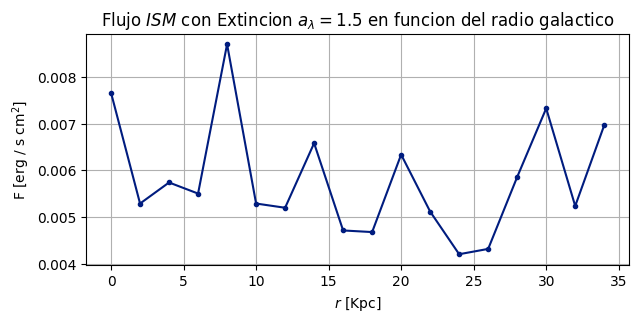

In [ ]:
fig = plt.figure(figsize=(7,3))
plt.title(f'Flujo $ISM$ con Extincion $a_λ={a_λ}$ en funcion del radio galactico')
plt.plot(ticks, fluxmin_extint, '.-')
plt.ylabel('F [erg / s cm$^{2}$]')
plt.xlabel('$r$ [Kpc]')
plt.grid()

### **D) Energia de los fotones con ley de Wien**

(1 pt) Teniendo en cuenta que la temperatura de estas estrellas es $T_O* ≈ 4 * 10^4 K$, calcule la energıa de los fotones del pico de emision, es decir con $λ_O* = λ_{\text{Wien}}(T_O*)$ y el numero de fotones por unidad de area por unidad de tiempo (flujo de fotones), generando una grafica similar a las anteriores.

* Compare con el valor medido en el medio interestelar
($10^{8}$ fotones cm$^{-2}$ s$^{-1}$).


* $^{a}$ https://advances.sciencemag.org/content/3/9/eaao2538.full

In [ ]:
# temperatura de estrellas [k]
To = 4*10**4

# Ley de Wien
b = 0.289775e-2 # [m/k]
λ_max = b /To # [m]

# Energia con Planck
nu_max = c/λ_max # [1/s]
E = h*1e7*nu_max   # [erg]

# flujo de fotones
flux_γ = fluxmin_extint/E # [1/s cm^2]

#### **Grafica del flujo de fotones**

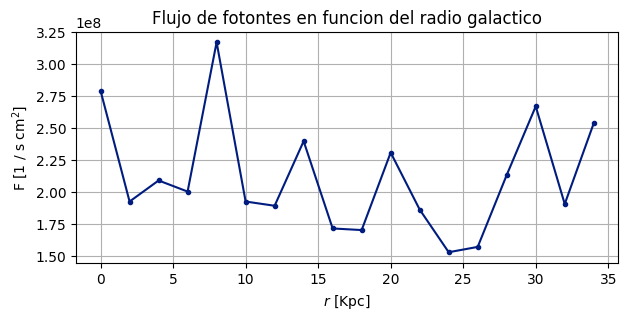

In [ ]:
fig = plt.figure(figsize=(7,3))
plt.title(f'Flujo de fotontes en funcion del radio galactico')
plt.plot(ticks, flux_γ, '.-')
plt.ylabel('F [1 / s cm$^{2}$]')
plt.xlabel('$r$ [Kpc]')
plt.grid()

Coincide en buena medida con el orden $10^8$ fotones/s cm$^{2}$

### **E) Temperatura de equilibrio del polvo interestelar**

(2 pt) El **flujo F$_{ISM}$** del campo interestelar de radiacion calienta los granos de polvo en el medio interestelar hasta cierta temperatura de equilibrio $T_g$. En promedio estos granos tienen un tamano $a ≈ 0.1$ μm.

Si cada grano de polvo fuera un cuerpo negro, reemitiria la radiacion absorbida con un pico de emision en $λ_g = λ_{Wien}$(Tg) segun la **Ley de Stefan-Boltzmann** ($F_{SB} = σT^4_g $). Dado que esta radiacion es infraroja ($λ_g > 2πa$) se cumple que $Q_λ ≈ (2πa/λ_g)^β$ (**teorıa de Mie**).
<br>

Esto significa que el flujo emitido por el polvo no es exactamente el de un cuerpo negro sino que sera modulado por $Q_λ$, de manera que $F_{em} ≈ F_{SB} Q_λ$. <br>

Suponiendo que los granos de polvo emiten toda la radiacion absorbida ($F_{em} = F_{abs} = F_{ISM}$), y tomando un valor de $β = 1.45$ **encuentre la temperatura de equilibrio** $T_g$ para los granos de polvo en el medio interestelar para cada uno de los valores de F_{ISM} del punto (C), y haga
una grafica de $T_{g}$ vs $r$ con los resultados.

* *Pista:* Deberıan dar cerca de 20 K.
* b https://ned.ipac.caltech.edu/level5/Sept14/Conroy/Conroy6.html



In [ ]:
β = 1.45
a = 0.1e-6 # tamaño granos de polvo [m]
σ = cts.sigma*1e7/(1e2)**2 # cte SB [W/m^2 K^4] a [erg/s cm^2 k^4]

# temperatura de eq
T = ( fluxmin_extint*b**β / ((2*pi*a)**β *σ) )**(1/(4+β))

#### **Grafica Temperatura de equilibrio del polvo**

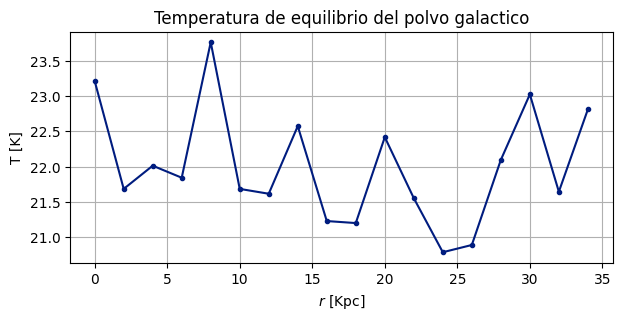

In [ ]:
fig = plt.figure(figsize=(7,3))
plt.title(f'Temperatura de equilibrio del polvo galactico')
plt.plot(ticks, T, '.-')
plt.xlabel('$r$ [Kpc]')
plt.ylabel('T [K]')
plt.grid()

Esta temperatura aumenta a medida que se tiene mayor numero de estrellas, por ejemplo con $2e4$ estrellas, los valores estan al rededor de los $19$K

### **F) Calculo del coeficiente de Extincion**

(1 pt) Si la densidad de numero del polvo es $n_d = 2 * 10^{-13} cm^{-3}$, calcule el coeficiente de extincion $a_λ$ en unidades de **[mag kpc$^{-1}$]** para $λ = λ_g$ usando la $T_g$ promedio.
¿Por que es menor que en (C)?

In [ ]:
# longitud de onda de equilibrio
λ_g = b/np.mean(T) # [m]

# coeficiente de eficiencia de extincion
Q_λ = (2*pi*a/λ_g)**β # [adim]

In [ ]:
# densidad de numero [cm^-3] a [m^-3]
n_d = 2*10**(-13)*(100**3)

# secciones eficases
σ_g = pi*a**2  # geometrica [m^2]
σ_λ = Q_λ*σ_g  # de absorcion [m^2]


# coeficiente de absorcion
k_λ = σ_λ*n_d # [1/m]

# coeficiente de extincion (a partir del polvo)
a_λ_polvo = 1.086*k_λ*(pc_m*1e3) # [mag/kpc]

In [ ]:
a_λ, a_λ_polvo

(1.5, 9.064355805373947e-05)

### **G) Intensidad con Transferencia Radiativa (Absorcion y Emision)**

(3 pt) Suponga que los granos de polvo estan distribuidos sobre todo el disco galactico, emitiendo (y absorbiendo) termicamente con una funcion fuente $S_ν = B_ν$ para $ν_g = c/λ_g$. Calcule (con la solucion de la ecuacion de transferencia radiativa) la intensidad $I_ν$ en el centro de la galaxia y emitida por el polvo galactico. Compare con el valor promedio medido $≈ 10^{-14}$ erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$ sr$^{-1}$

* c https://indico.cern.ch/event/506272/contributions/2167227/attachments/1275357/1891894/Ganga.pdf


In [ ]:
# densidad de columna
N = n_d * r_gal*(pc_m*1e3) # [1/m^2]

# Profundidad optica
τ_nu = σ_λ*N # [adim] = k_λ * r_gal*(pc_m*1e3)

In [ ]:
# frecuencia del polvo en equilibrio
nu = c/λ_g # [1/s]

# Ley de Plank
T = T.astype(np.float64)
S_nu = 2*h*nu**3 / (c**2*(np.exp(h*nu/(k*T))-1)) # [J/m^2]

# intensidad incidente en el medio
I_nuo = S_nu  # [J/m^2]

# solucion a la ecuacion de trasnferencia rad
I_nu = I_nuo*np.exp(-τ_nu) + S_nu*(1-np.exp(-τ_nu)) # [J/m^2]
I_nu = np.mean(I_nu*1e7/(100**2)) # [erg/cm^2 s hz]
I_nu

1.2341967042790072e-12

este valor difiere en un par de ordenes de magnitud con el esperado de $1e-14$, pero se aproxima, ademas, cuando se toma un numero de estrellas $2e4$ cambia a un orden de $1e-13$

### **H) Modelo realista del polvo: Teoria de Mie y radio fiducial**

(3 pt) Considere un modelo mas realista para el polvo, donde hay $dn_d$ granos por unidad de volumen con radios entre $a$ y $a + da$, y su distribucion sigue la relacion $dn_d/da = C \ a^{-3.5}$, con $C = 6.4 * 10^{-26}$ cm$^{-0.5}$. <br>

Tome el maximo radio en la distribucion como $a_{max} = 0.09$ μm, y el mınimo como $a_{min} = 0$. <br>

Calcule el coeficiente de extincion $a_λ$ teniendo en cuenta la **teorıa de Mie** para calcular la seccion eficaz $σ_λ$ (similar al punto **(E)**, con $β = 1.45$ cuando $λ > 2πa$, y $β = 0$ para los demas casos) para $λ = λ_{Wien}(T_{O*})$ en unidades de [mag kpc$^{-1}$], y calcule el radio fiducial $R_V$ recordando que $A_λ ∝ a_λ$.

* *Pista*: $a_λ$ deberıa ser similar al valor citado en el punto (C), y $R_V ≈ 3.1$

In [ ]:
C = (6.4e-26)*(100*1e9)**1/2 # [cm^-0.5]
a_max = 0.09e-6 # [m]
a_min = 0 # [m]

# long onda bandas
λV = 550 # [nm]
λB = 440 # [nm] λ_g

con la integracion del coeficiente de extincion, resulta en las ecuaciones:

In [ ]:
# coeficiente extincion: de las propiedades del polvo
k_λV = C*pi*( (2*pi/λV)**β *(87.5)**0.95/0.95 - (90)**(-0.5)/0.5 + (87.5)**(-0.5)/0.5 ) # [1/nm]

k_λB = C*pi*( (2*pi/λB)**β *(70)**0.95/0.95 - (90)**(-0.5)/0.5 + (70)**(-0.5)/0.5 ) # [1/nm]

aa_λ = (k_λV+k_λB) *1.086*1e9*pc_m*1e3  # [1/kpc]
aa_λ

90764346616908.53